In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, metrics, svm
from sklearn.model_selection import train_test_split

In [2]:
#ladowanie danych ze zbiotu digits
digits = datasets.load_digits()

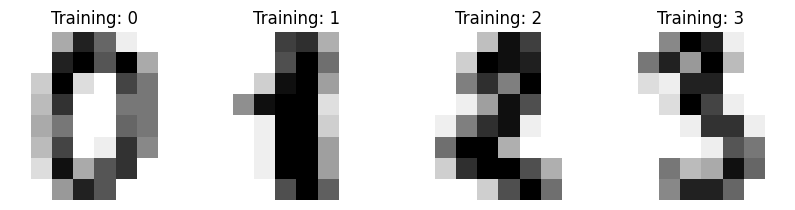

In [3]:
#wizualizacja danych
_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, label in zip(axes, digits.images, digits.target):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"Training: {label}")
plt.show()

In [4]:
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))

print(n_samples)

1797


In [71]:
#budowa klasyfikatora
clf = svm.SVC(gamma=0.001, C=1.)
X_train, X_test, y_train, y_test = train_test_split(
    data, digits.target, test_size=0.5, shuffle=False
)

In [72]:
clf.fit(X_train, y_train)

SVC(gamma=0.001)

In [73]:
predicted = clf.predict(X_test)

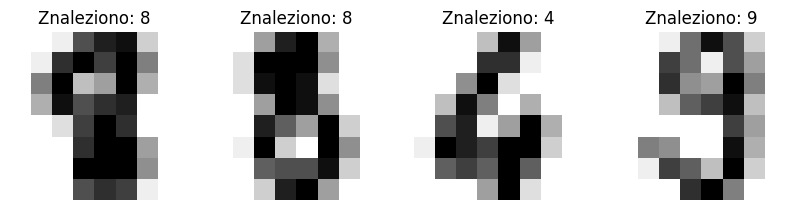

In [8]:
#wizualizacja danych
_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, prediction in zip(axes, X_test, predicted):
    ax.set_axis_off()
    image = image.reshape(8, 8)
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"Znaleziono: {prediction}")
plt.show()

In [74]:
#ocena modelu
print(f"Raport klasyfikacyjny dla clf: {clf}\n{metrics.classification_report(y_test,predicted)}\n")

Raport klasyfikacyjny dla clf: SVC(gamma=0.001)
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        88
           1       0.99      0.97      0.98        91
           2       0.99      0.99      0.99        86
           3       0.98      0.87      0.92        91
           4       0.99      0.96      0.97        92
           5       0.95      0.97      0.96        91
           6       0.99      0.99      0.99        91
           7       0.96      0.99      0.97        89
           8       0.94      1.00      0.97        88
           9       0.93      0.98      0.95        92

    accuracy                           0.97       899
   macro avg       0.97      0.97      0.97       899
weighted avg       0.97      0.97      0.97       899




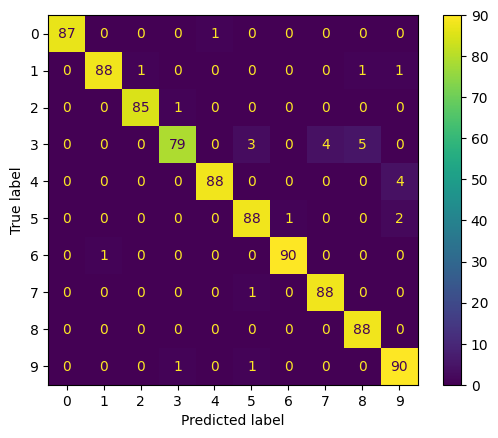

In [75]:
Printer = metrics.ConfusionMatrixDisplay.from_predictions(y_test, predicted)
